#### Building input pipelines:
- In case the data is large and cannot be fit into the computer memory (one tensor), we will need to lead the data from the main storage device (e.g., the hard drive) in chunks, that is, batch by batch.
- In addition, same to pipleline in sklearn, we need to construct a data-processing pipeline to apply certain transformation and preprocessing steps to our data (scaling, centering, adding noise to prevent overfitting)
- Helpful classes: **Dataset** and **DataLoader**

#### DataLoader: torch.utils.data.DataLoader() - creates dataset to load iteratively

In [1]:
from torch.utils.data import DataLoader
import torch

# iteration
t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)

for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [2]:
data_loader = DataLoader(t, batch_size=3, drop_last=False) # create chunks of 3 ~ splitting

# batch (mini-batch) iteration
for i, batch in enumerate(data_loader):
    print(f"batch {i}: ", batch)


batch 0:  tensor([0., 1., 2.])
batch 1:  tensor([3., 4., 5.])


#### Dataset

In [3]:
from torch.utils.data import Dataset
import numpy as np
from typing import Tuple 

class JoinDataset(Dataset):
    def __init__(self, x: torch.Tensor | np.ndarray, y: torch.Tensor | np.ndarray):
        assert len(x) == len(y), "length x != length y"
        self.x = torch.as_tensor(x)
        self.y = torch.as_tensor(y)
    
    def __len__(self) -> int:
        return len(self.x)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.x[idx], self.y[idx]

In [4]:
torch.manual_seed(1)

t_x = torch.rand([4,3], dtype= torch.float32)
t_y = torch.arange(4)

joint_dataset = JoinDataset(t_x, t_y)

for example in joint_dataset:
    print('x: ', example[0], 'y: ', example[1])

x:  tensor([0.7576, 0.2793, 0.4031]) y:  tensor(0)
x:  tensor([0.7347, 0.0293, 0.7999]) y:  tensor(1)
x:  tensor([0.3971, 0.7544, 0.5695]) y:  tensor(2)
x:  tensor([0.4388, 0.6387, 0.5247]) y:  tensor(3)


In [5]:
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)
for i, batch in enumerate(data_loader):
    print(f"Batch {i}:\n x: {batch[0]} \n y: {batch[1]} ")

Batch 0:
 x: tensor([[0.7576, 0.2793, 0.4031],
        [0.4388, 0.6387, 0.5247]]) 
 y: tensor([0, 3]) 
Batch 1:
 x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7347, 0.0293, 0.7999]]) 
 y: tensor([2, 1]) 


In [6]:
for epoch in range(2):
    print(f'\nEpoch {epoch+1}')
    for i, batch in enumerate(data_loader):
        print(f"Batch {i}:\n x: {batch[0]} \n y: {batch[1]} ")


Epoch 1
Batch 0:
 x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
 y: tensor([1, 3]) 
Batch 1:
 x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
 y: tensor([2, 0]) 

Epoch 2
Batch 0:
 x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
 y: tensor([3, 2]) 
Batch 1:
 x: tensor([[0.7347, 0.0293, 0.7999],
        [0.7576, 0.2793, 0.4031]]) 
 y: tensor([1, 0]) 


#### Creating a dataset from files on local storage disk
- **pathlib.Path**: generate a list of image files
- **PIL.Image** to read the image file content and transforms into torchvision

In [7]:
import pathlib
import os

imgdir_path = pathlib.Path("cats_and_dogs_images")
print(list(imgdir_path.glob('*.jpg')))

[PosixPath('cats_and_dogs_images/cat-01.jpg'), PosixPath('cats_and_dogs_images/cat-02.jpg'), PosixPath('cats_and_dogs_images/dog-03.jpg'), PosixPath('cats_and_dogs_images/dog-02.jpg'), PosixPath('cats_and_dogs_images/dog-01.jpg'), PosixPath('cats_and_dogs_images/cat-03.jpg')]


In [8]:
file_list = sorted([f for f in list(imgdir_path.glob('*.jpg'))])
for f in file_list:
    print(f, "-----" , os.path.basename(f))

cats_and_dogs_images/cat-01.jpg ----- cat-01.jpg
cats_and_dogs_images/cat-02.jpg ----- cat-02.jpg
cats_and_dogs_images/cat-03.jpg ----- cat-03.jpg
cats_and_dogs_images/dog-01.jpg ----- dog-01.jpg
cats_and_dogs_images/dog-02.jpg ----- dog-02.jpg
cats_and_dogs_images/dog-03.jpg ----- dog-03.jpg


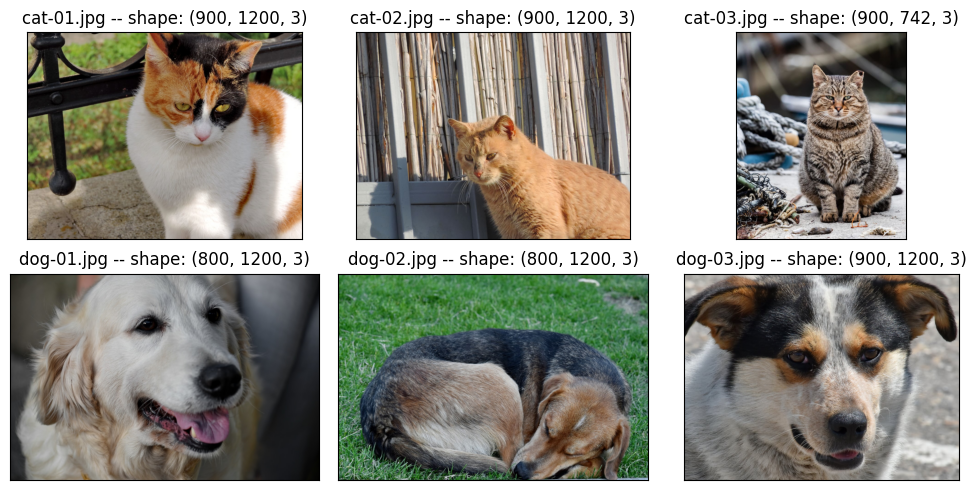

In [9]:
import matplotlib.pyplot as plt
import os
from PIL import Image

fig = plt.figure(figsize=(10, 5))

for idx, file in enumerate(file_list):
    img = Image.open(file)
    ax = fig.add_subplot(2, 3, idx+1)
    ax.imshow(img)
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(f"{os.path.basename(file)} -- shape: {np.asarray(img).shape}")

plt.tight_layout()
plt.show()

In [10]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [11]:
class ImageDataset(Dataset):
    def __init__(self, file_list: list, labels: list | np.ndarray | torch.Tensor):
        self.file_list = file_list
        self.labels = labels
    
    def __getitem__(self, index) -> Tuple[str, int]:
        file = self.file_list[index]
        label = self.labels[index]
        return file, label
    
    def __len__(self) -> int:
        return len(self.file_list)

In [12]:
image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

cats_and_dogs_images/cat-01.jpg 0
cats_and_dogs_images/cat-02.jpg 0
cats_and_dogs_images/cat-03.jpg 0
cats_and_dogs_images/dog-01.jpg 1
cats_and_dogs_images/dog-02.jpg 1
cats_and_dogs_images/dog-03.jpg 1


In [13]:
# transformation
import torchvision.transforms as transforms
img_height, img_width = 256, 256
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width))
])

In [14]:
# update class ImageDataset
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __getitem__(self, idx): # do the transforms here
        file = self.file_list[idx]
        label = self.labels[idx]
        img = Image.open(file)
        if self.transform is not None:
            img = self.transform(img)
        return img, label
    
    def __len__(self):
        return len(self.labels)

In [15]:
image_dataset = ImageDataset(file_list, labels, transform=transform)

In [16]:
for i, (img, label) in enumerate(image_dataset):
    print(img.numpy().shape)

(3, 256, 256)
(3, 256, 256)
(3, 256, 256)
(3, 256, 256)
(3, 256, 256)
(3, 256, 256)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


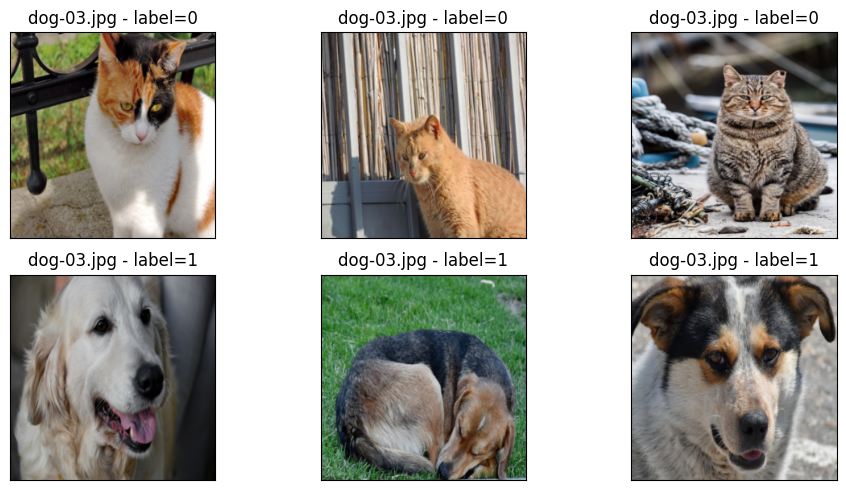

In [17]:
fig = plt.figure(figsize=(10, 5))

for idx, (img, label) in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, idx+1)
    ax.imshow(img.numpy().transpose(1,2,0))
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(f"{os.path.basename(file)} - {label=}")

plt.tight_layout()
plt.show()

#### Fetching available datasets from the torchvision.datasets library

**CelebFaces Attributes Dataset (CelebA)**
- more than 200k face images, 10k identities
- 5 landmark locations, 40 attributes annotations per image
- 3 subsets: train, test, valid -> access via **split**

In [25]:
import torchvision

image_path = '../data'
celeba_dataset = torchvision.datasets.CelebA(
    image_path, target_type="attr", download=False
)

In [26]:
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

In [28]:
example = celeba_dataset[0]
print(example) # (PIL.Image, attributes) -> need to reformat it as tuple of (features tensor, label)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x7E38FADE0AD0>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


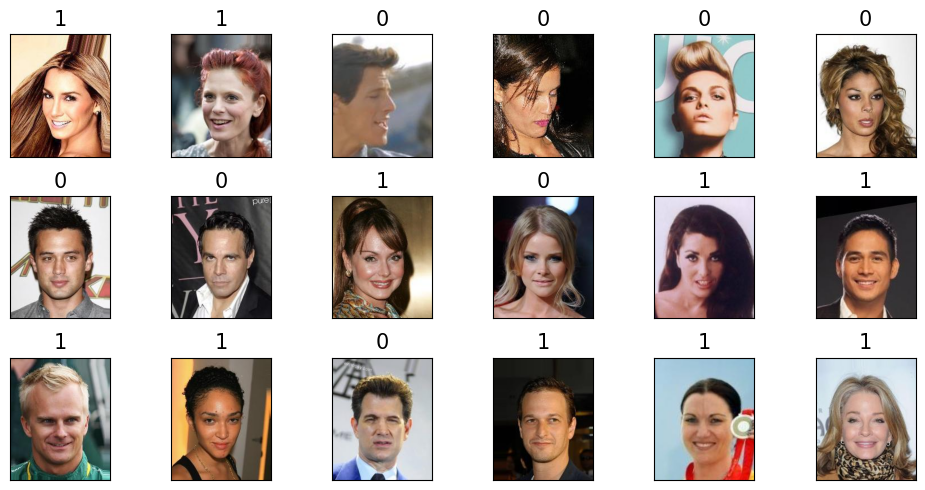

In [35]:
from itertools import islice

fig = plt.figure(figsize=(10,5))

for i, (image, attributes) in islice(enumerate(celeba_dataset), 18):
    ax = fig.add_subplot(3, 6, i+1)
    ax.imshow(image)
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(attributes[31].numpy(), size=15)

plt.tight_layout()
plt.show()

In [36]:
image_path = "../data"

mnist_dataset = torchvision.datasets.MNIST(image_path, "train", download="True")

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


In [37]:
assert isinstance(mnist_dataset, torch.utils.data.Dataset)

In [38]:
example = next(iter(mnist_dataset))
print(example)

(<PIL.Image.Image image mode=L size=28x28 at 0x7E38E2D438C0>, 5)


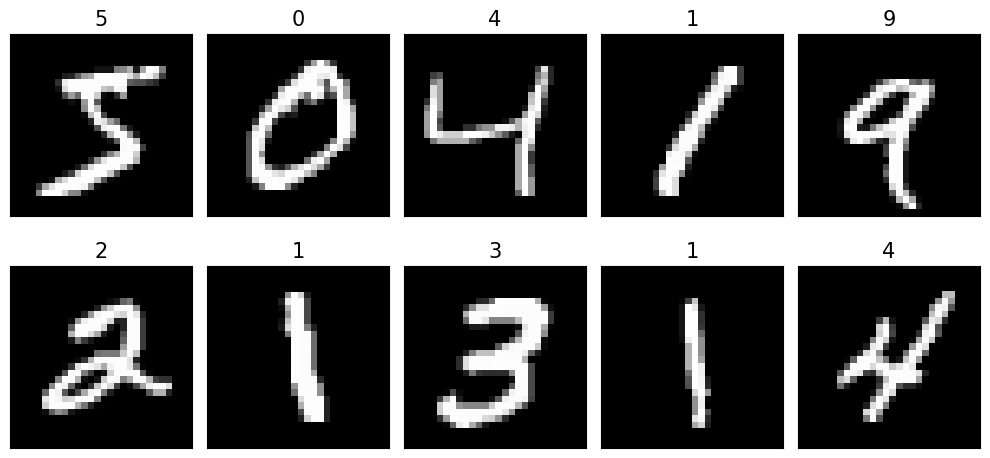

In [43]:
fig = plt.figure(figsize=(10, 5))

for i, (image, label) in islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.imshow(image, cmap="gray")
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(label, size=15)

plt.tight_layout()
plt.show()
